In [ ]:
!pip install keras keras-hub --upgrade -q
import os
os.environ["KERAS_BACKEND"] = "jax"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.21.1 requires keras-hub==0.21.1, but you have keras-hub 0.23.0 which is incompatible.


In [ ]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

In [ ]:
from keras.datasets import cifar10

# Load the dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 32*32*3)
x_test = x_test.reshape(-1, 32*32*3)

In [ ]:
import keras
from keras import layers
from keras.layers import Input

model = keras.Sequential([
    Input(shape=(3072,)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adamw",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [ ]:
x_train.shape

(50000, 3072)

In [ ]:
x_val = x_train[-5000:]
y_val = y_train[-5000:]

x_train = x_train[:45000]
y_train = y_train[:45000]

In [ ]:
y_train.shape

(45000, 1)

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=40,
    batch_size=64,
    validation_data=(x_val, y_val),
    validation_batch_size=128
)

Epoch 1/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.3194 - loss: 1.8796 - val_accuracy: 0.3616 - val_loss: 1.7590
Epoch 2/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.3932 - loss: 1.6895 - val_accuracy: 0.4268 - val_loss: 1.6272
Epoch 3/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.4280 - loss: 1.5994 - val_accuracy: 0.4254 - val_loss: 1.6197
Epoch 4/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.4475 - loss: 1.5436 - val_accuracy: 0.4388 - val_loss: 1.5923
Epoch 5/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.4657 - loss: 1.4980 - val_accuracy: 0.4678 - val_loss: 1.4995
Epoch 6/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.4783 - loss: 1.4614 - val_accuracy: 0.4648 - val_loss: 1.5160
Epoch 7/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.4857 - loss: 1.4375 - val_accuracy: 0.4706 - val_loss: 1.4871
Epoch 8/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.4994 - loss: 1.4020 - 

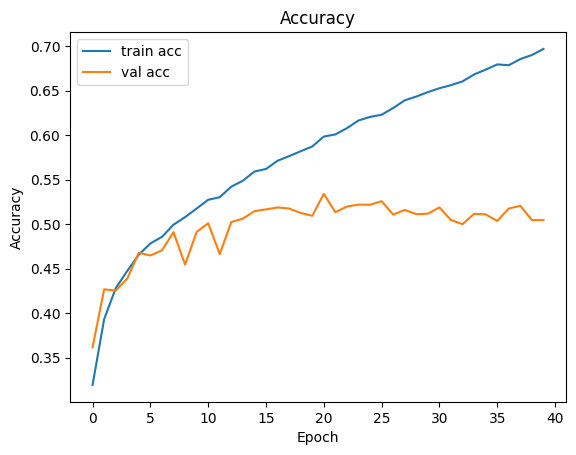

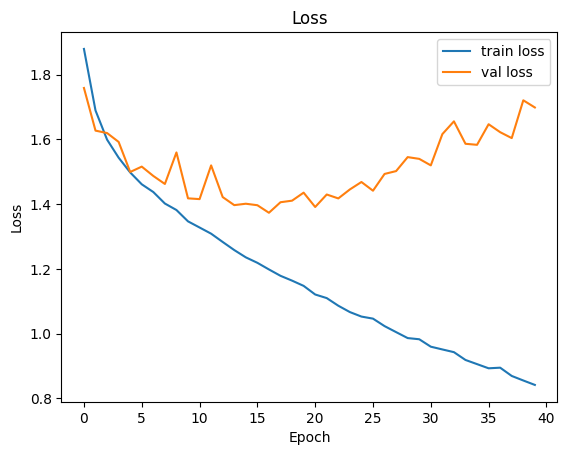

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
# We retrain the model to the optimal epochs to avoid overfitting

new_model = keras.Sequential([
    Input(shape=(3072,)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

new_model.compile(
    optimizer="adamw",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = new_model.fit(
    x_train,
    y_train,
    epochs=4,
    batch_size=64,
    validation_data=(x_val, y_val),
    validation_batch_size=128
)

Epoch 1/4
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.3145 - loss: 1.8849 - val_accuracy: 0.3780 - val_loss: 1.7505
Epoch 2/4
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.3927 - loss: 1.6896 - val_accuracy: 0.3996 - val_loss: 1.6520
Epoch 3/4
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.4229 - loss: 1.6092 - val_accuracy: 0.4102 - val_loss: 1.6327
Epoch 4/4
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.4471 - loss: 1.5423 - val_accuracy: 0.4484 - val_loss: 1.5481


In [ ]:
#output model
new_model.save('FCNN_cifar10_0_4471_adamw.keras')